# Cenário 1 – Identificação de Vulnerabilidades em Dispositivos IoT

Este notebook gera dados simulados e treina modelos de classificação (Random Forest, SVM e XGBoost) para identificar dispositivos vulneráveis.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 2000

firmware_age = np.random.randint(0, 10, n)
open_ports = np.random.randint(1, 20, n)
weak_password = np.random.binomial(1, 0.4, n)
traffic_mb_day = np.random.normal(1000, 400, n).clip(50, None)
failed_logins = np.random.poisson(5, n)

risk_score = (
    0.35 * firmware_age +
    0.25 * open_ports +
    2.5 * weak_password +
    0.15 * failed_logins +
    np.random.normal(0, 1, n)
)

vulnerable = (risk_score > np.percentile(risk_score, 60)).astype(int)

df = pd.DataFrame({
    'firmware_age': firmware_age,
    'open_ports': open_ports,
    'weak_password': weak_password,
    'traffic_mb_day': traffic_mb_day,
    'failed_logins': failed_logins,
    'vulnerable': vulnerable
})

df.head()


,firmware_age,open_ports,weak_password,traffic_mb_day,failed_logins,vulnerable
0,6,10,0,573.546691,4,0
1,3,7,0,1024.484949,6,0
2,7,9,0,1044.473257,6,1
3,4,17,0,1150.985888,5,0
4,6,11,0,954.504571,7,0


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop('vulnerable', axis=1)
y = df['vulnerable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(1400, 5) (600, 5)


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))


Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       360
           1       0.84      0.75      0.79       240

    accuracy                           0.84       600
   macro avg       0.84      0.82      0.83       600
weighted avg       0.84      0.84      0.84       600



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([    
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_svm))
print(classification_report(y_test, pred_svm))


Accuracy: 0.8416666666666667
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       360
           1       0.83      0.77      0.79       240

    accuracy                           0.84       600
   macro avg       0.84      0.83      0.83       600
weighted avg       0.84      0.84      0.84       600



In [6]:
try:
    from xgboost import XGBClassifier

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )

    xgb.fit(X_train, y_train)

    pred_xgb = xgb.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, pred_xgb))
    print(classification_report(y_test, pred_xgb))

except ImportError:
    print("XGBoost não está instalado. Execute: pip install xgboost")


Accuracy: 0.8483333333333334
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       360
           1       0.83      0.78      0.80       240

    accuracy                           0.85       600
   macro avg       0.85      0.84      0.84       600
weighted avg       0.85      0.85      0.85       600



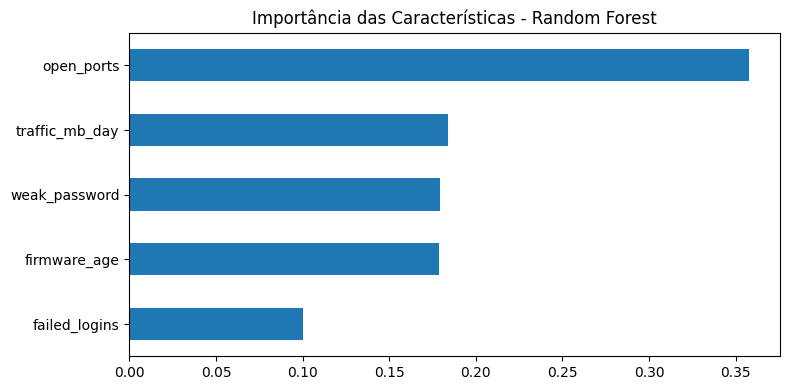

In [7]:
import matplotlib.pyplot as plt

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,4))
importances.plot(kind='barh')
plt.title('Importância das Características - Random Forest')
plt.tight_layout()
plt.show()
